In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
from pyproj import CRS
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False

from plot_scale1 import plotscale

## 数据处理

In [ ]:
gdf = gpd.read_file('data/shp/county.shp')
province = gpd.read_file(r"E:\台式机代码\2024\省级")  # https://www.shengshixian.com/
ten_lines = gpd.read_file(r"E:\台式机代码\2024\十段线\十段线.shp")  # https://www.shengshixian.com/
gdf

,AREA,PERIMETER,LEVEL3_,LEVEL3_ID,AD2004,NAME2004,geometry
0,2.468910,9.02838,1,1,232723,漠河县,"POLYGON ((123.31728 52.35658, 123.29559 52.360..."
1,1.860620,7.96627,2,2,232722,塔河县,"POLYGON ((124.27914 53.34561, 124.28529 53.341..."
2,1.883120,11.70930,3,3,231121,嫩江县,"POLYGON ((126.59299 49.16717, 126.59437 49.166..."
3,1.799470,6.80484,4,4,231101,黑河市市辖区,"POLYGON ((126.49651 49.7744, 126.48713 49.7776..."
4,3.066640,8.35931,5,5,150727,新巴尔虎右旗,"POLYGON ((115.53142 48.13883, 115.533 48.14248..."
...,...,...,...,...,...,...,...
2382,0.096528,7.67322,2383,2384,810000,香港特别行政区,"MULTIPOLYGON (((114.03947 22.50442, 114.0396 2..."
2383,0.328667,3.22120,2384,2385,451422,宁明县,"POLYGON ((107.54013 21.8664, 107.54572 21.8609..."
2384,0.246116,2.55957,2385,2386,450621,上思县,"POLYGON ((107.54013 21.8664, 107.54132 21.8702..."
2385,0.177405,11.17950,2386,2387,910000,None,"MULTIPOLYGON (((120.9744 31.7883, 120.97532 31..."


<Axes: >

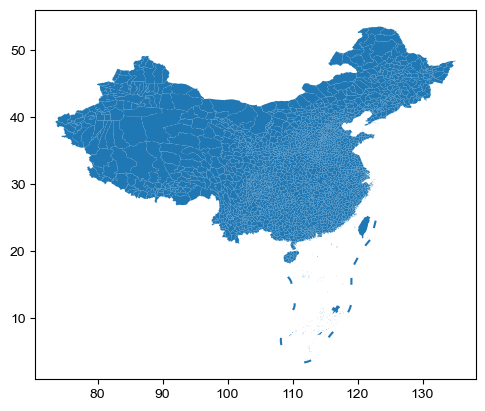

In [3]:
ax = gdf.plot()
ten_lines.plot(ax=ax)

In [4]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
csvs = [csv for csv in os.listdir('data') if csv.endswith('.csv')]  # https://doi.org/10.5281/zenodo.14000094
csvs

['FloodInventory_2000.csv',
 'FloodInventory_2001.csv',
 'FloodInventory_2002.csv',
 'FloodInventory_2003.csv',
 'FloodInventory_2004.csv',
 'FloodInventory_2005.csv',
 'FloodInventory_2006.csv',
 'FloodInventory_2007.csv',
 'FloodInventory_2008.csv',
 'FloodInventory_2009.csv',
 'FloodInventory_2010.csv',
 'FloodInventory_2011.csv',
 'FloodInventory_2012.csv',
 'FloodInventory_2013.csv',
 'FloodInventory_2014.csv',
 'FloodInventory_2015.csv',
 'FloodInventory_2016.csv',
 'FloodInventory_2017.csv',
 'FloodInventory_2018.csv',
 'FloodInventory_2019.csv',
 'FloodInventory_2020.csv',
 'FloodInventory_2021.csv',
 'FloodInventory_2022.csv']

In [6]:
# 合并数据
df = pd.DataFrame()

for csv in csvs:
    df0 = pd.read_csv(os.path.join('data', csv))
    df = pd.concat([
        df,
        df0
    ])

In [7]:
df = df.drop(columns=['Unnamed: 7','Unnamed: 10'])

In [8]:
df

,Year,PAC,Province,County,City,Occurrence,Time1,Time2,Time3,Time4
0,2000.0,130131,Hebei Province,Pingshan County,Shijiazhuang City,1,July,NaN,NaN,NaN
1,2000.0,130110,Hebei Province,Luquan District,Shijiazhuang City,1,July,NaN,NaN,NaN
2,2000.0,130121,Hebei Province,Jingxing County,Shijiazhuang City,1,July,NaN,NaN,NaN
3,2000.0,130503,Hebei Province,Xindu District,Xingtai City,1,20-Jul,NaN,NaN,NaN
4,2000.0,130502,Hebei Province,Xiangdu District,Xingtai City,1,20-Jul,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
351,2022.0,500108,Chongqing,South Bank,Chongqing,1,26-June,NaN,NaN,NaN
352,2022.0,500113,Chongqing,Banan District,Chongqing,1,26-June,NaN,NaN,NaN
353,2022.0,500115,Chongqing,Changshou District,Chongqing,1,26-June,NaN,NaN,NaN
354,2022.0,500116,Chongqing,Jiangjin District,Chongqing,1,26-June,NaN,NaN,NaN


In [9]:
gdf = gdf.rename(columns={'AD2004':'PAC'})

([], [])

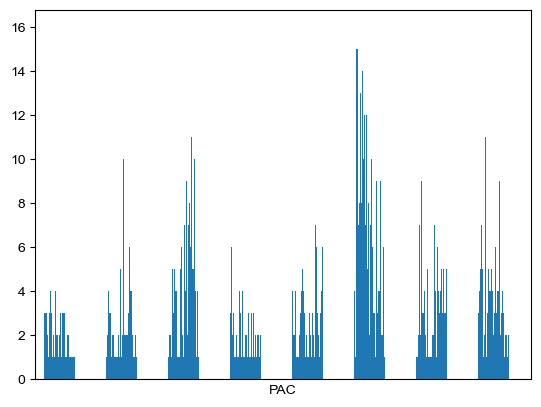

In [10]:
df.groupby('PAC').size().plot(kind='bar')
plt.xticks([])

In [11]:
results = []
for csv in csvs:
    df0 = pd.read_csv(os.path.join('data', csv))
    gdf0 = gdf.merge(
        df0.groupby('PAC', as_index=False)
          .agg({'Occurrence': 'sum'})
          .rename(columns={'Occurrence': 'Counts'}),
        on='PAC',
        how='left'
    ).dropna(subset=['Counts'])

    gdf0_centroid = gdf0.copy()
    gdf0_centroid['geometry'] = gdf0_centroid.geometry.centroid

    if gdf0_centroid.crs != province.crs:
        gdf0_centroid = gdf0_centroid.to_crs(province.crs)

    linked = gpd.sjoin(
        gdf0_centroid,
        province[['ENG_NAME', 'geometry']],
        how='left',
        predicate='within'
    )

    stats = (
        linked.groupby('ENG_NAME', as_index=False)
              .agg({'Counts': 'sum'})
              .assign(File=csv)
    )
    
    results.append(stats)

province_summary = pd.concat(results, ignore_index=True)

C:\Users\15499\AppData\Local\Temp\ipykernel_22876\2059359865.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf0_centroid['geometry'] = gdf0_centroid.geometry.centroid
C:\Users\15499\AppData\Local\Temp\ipykernel_22876\2059359865.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf0_centroid['geometry'] = gdf0_centroid.geometry.centroid
C:\Users\15499\AppData\Local\Temp\ipykernel_22876\2059359865.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf0_centroid['geometry'] = gdf0_centroid.geometry.centroid
C:\Users\15499\AppData\Local\Temp\ipykernel_22876\20593

In [12]:
province_summary['Year'] = province_summary['File'].apply(lambda x: x.split('_')[1].split('.')[0])
province_summary

,ENG_NAME,Counts,File,Year
0,Anhui,1.0,FloodInventory_2000.csv,2000
1,Chongqing,1.0,FloodInventory_2000.csv,2000
2,Fujian,22.0,FloodInventory_2000.csv,2000
3,Guangdong,2.0,FloodInventory_2000.csv,2000
4,Guangxi,4.0,FloodInventory_2000.csv,2000
...,...,...,...,...
474,Shanxi,1.0,FloodInventory_2022.csv,2022
475,Sichuan,14.0,FloodInventory_2022.csv,2022
476,Xinjiang,2.0,FloodInventory_2022.csv,2022
477,Yunnan,8.0,FloodInventory_2022.csv,2022


In [ ]:
# province.merge(
#     province_summary.groupby('ENG_NAME').agg({'Counts':'sum'}).reset_index(),
#     on='ENG_NAME',
#     how='left'
# ).fillna(0)[['省','Counts']]['Counts'].sum()

3748.0

In [13]:
# 属性连接
gdf = gdf.merge(
    df.groupby('PAC', as_index=False).agg({'Occurrence': 'sum'}).rename(columns={'Occurrence':'Counts'}),
    on='PAC',
    how='left'
)
gdf.fillna({'Counts': 0}, inplace=True)
gdf['Counts'] = gdf['Counts'].astype(int)

## 制图

### 热力图

In [14]:
heatmap_data = province_summary.pivot_table(
    index='Year',
    columns='ENG_NAME',
    values='Counts',
    fill_value=0
)

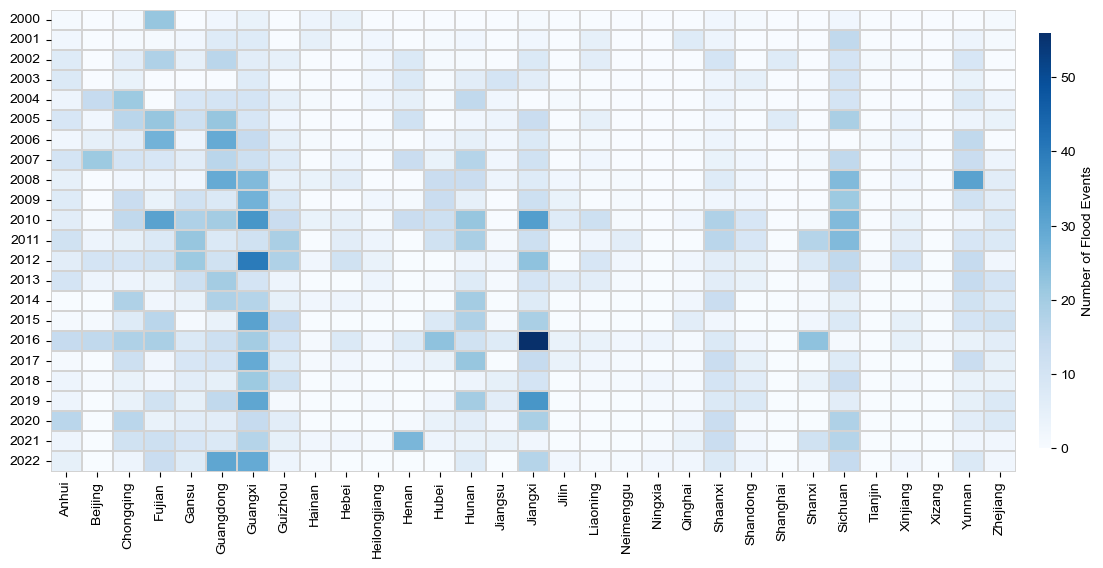

In [15]:
fig, ax = plt.subplots(1,1, figsize=(15,6))
ax = sns.heatmap(
    data=heatmap_data,
    cmap='Blues',
    cbar=True,
    square=False,  # 不强制正方形单元格
    linewidths=0.1,  # 单元格边框宽度
    linecolor='lightgrey',  # 边框颜色
    xticklabels=True,
    yticklabels=True,
    cbar_kws={
        'label': 'Number of Flood Events',  # 颜色条标题
        # 'ticks': [0, 2, 4, 6, 8, 10, heatmap_data.values.max()],
        'shrink': 0.9,  # 颜色条缩放比例（适配图大小）
        'aspect': 35,  # 颜色条宽高比
        'pad': 0.02  # 颜色条与热图的间距
    }
)
plt.xlabel('')
plt.ylabel('')
plt.show()

### 空间分布图

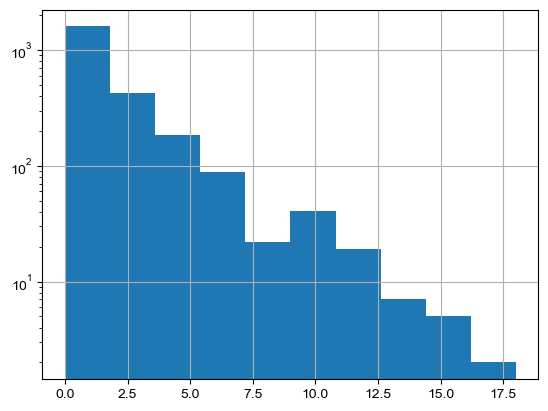

In [16]:
gdf.Counts.hist()
plt.yscale('log')

In [17]:
colors = [
    '#ffffff',
    '#dce6f2',
    '#b3c9e5',
    '#80a5d8',
    '#5986cc',
    '#3366c0',
    '#1a4db3'
]
query_word = [
    'Counts <= 0',
    'Counts > 0 and Counts <= 2',
    'Counts > 2 and Counts <= 4',
    'Counts > 4 and Counts <= 6',
    'Counts > 6 and Counts <= 8',
    'Counts > 8 and Counts <= 10',
    'Counts > 10'
]

In [18]:
# 提前转换投影
china_crs = ccrs.AlbersEqualArea(
    central_longitude=105,
    central_latitude=0,
    standard_parallels=(25, 47)
)
 
# 转换数据到投影坐标系
province_proj = province.to_crs(china_crs.proj4_init)
ten_lines_proj = ten_lines.to_crs(china_crs.proj4_init)
gdf_proj = gdf.to_crs(china_crs.proj4_init)

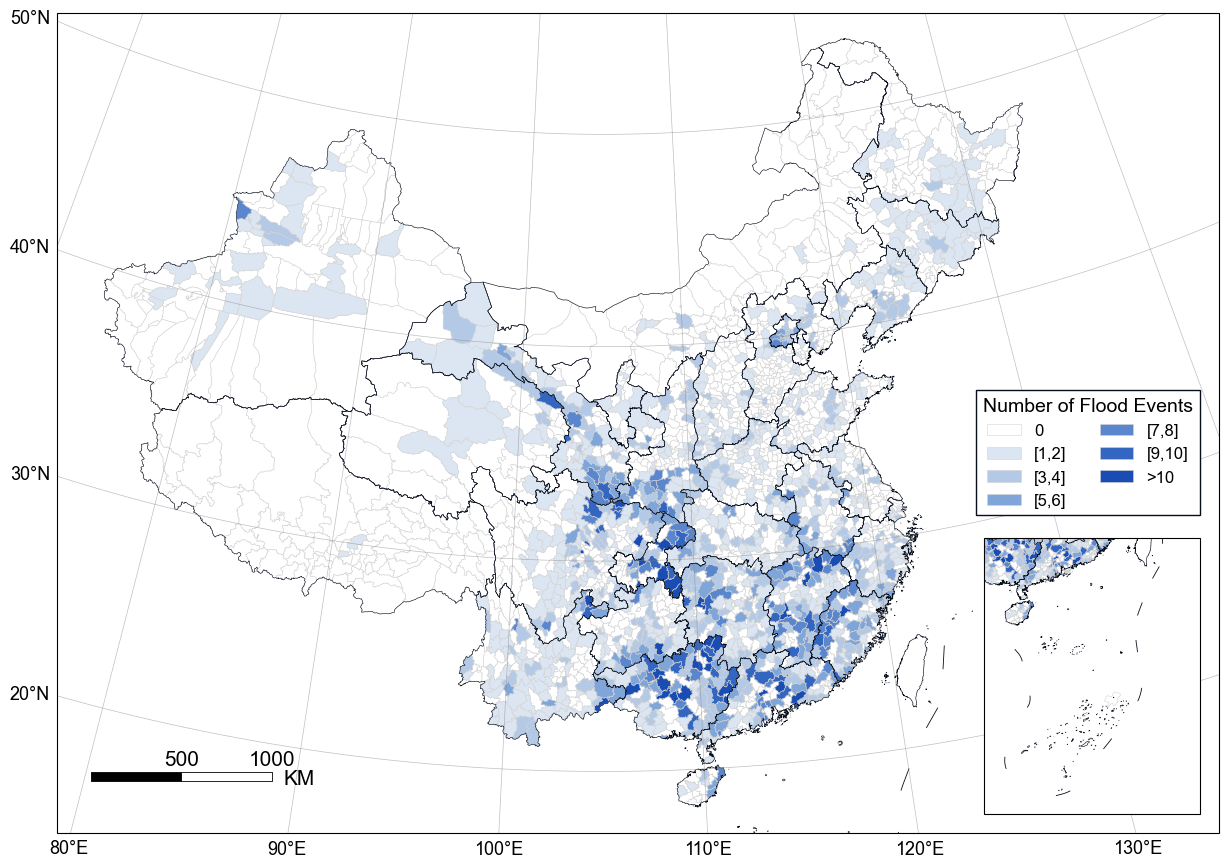

In [19]:
fig = plt.figure(figsize=(15, 12))
ax = plt.subplot(1, 1, 1, projection=china_crs)

# 主图
province_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#060d1b',
    linewidth=0.4,
    zorder=2
)
ten_lines_proj.plot(
    ax=ax,
    color='#060d1b',
    linewidth=0.6,
    zorder=2
)
for i in range(len(colors)):
    gdf_proj.query(query_word[i]).plot(
        ax=ax,
        color=colors[i],
        lw=0.4,
        ec='lightgrey',
        zorder=1
    )
# 设置范围时仍然使用地理坐标系
ax.set_extent([78.5, 135, 17, 53], crs=ccrs.PlateCarree())
# 网格线使用地理坐标系标注
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='-'
)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.FixedLocator(range(70, 141, 10))
gl.ylocator = mticker.FixedLocator(range(10, 61, 10))
gl.xlabel_style = {
    'rotation': 0, 
    'ha': 'center',
    'va': 'top',
    'size': 13
}
gl.ylabel_style = {
    'rotation': 0, 
    'va': 'center',
    'size': 13
}


# 子图
inset_pos = [0.73, 0.169, 0.17, 0.23]  # [left, bottom, width, height]
inset_ax = fig.add_axes(inset_pos, projection=china_crs)
# 筛选并转换子图区域的数据
southern_provinces = province[province['省'].isin(['广东省','广西壮族自治区','福建省','海南省','台湾省'])]
southern_provinces_proj = southern_provinces.to_crs(china_crs.proj4_init)
southern_provinces_proj.plot(
    ax=inset_ax,
    facecolor='none',
    edgecolor='#060d1b',
    linewidth=0.4,
    zorder=2
)
ten_lines_proj.plot(
    ax=inset_ax,
    color='#060d1b',
    linewidth=0.6,
    zorder=2
)
for i in range(len(colors)):
    gdf_proj.query(query_word[i]).plot(
        ax=inset_ax,
        color=colors[i],
        lw=0.4,
        ec='lightgrey',
        zorder=1
    )
inset_ax.set_extent([107, 122, 2, 24], crs=ccrs.PlateCarree())
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')


# 指北针/比例尺
compass_scale_ax = fig.add_axes([0.125, 0.17, 0.15, 0.06], zorder=0)
plotscale(
    compass_scale_ax,
    bounds=province.total_bounds,
    textsize=15,
    compasssize=0.7,
    crs_is_projected=True,
    accuracy=125000,
    style=2
)
compass_scale_ax.axis('off')

# 图例
labels = ['0', '[1,2]', '[3,4]', '[5,6]', '[7,8]', '[9,10]', '>10']
legend_elements = [
    Patch(
        facecolor=colors[i],
        edgecolor='lightgrey',
        linewidth=0.4,
        label=labels[i],
    ) for i in range(len(colors))
]
ax.legend(
    handles=legend_elements,
    title='Number of Flood Events',
    title_fontsize=14,
    fontsize=12,
    loc='upper right',
    bbox_to_anchor=(0.99, 0.55),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor='#060d1b',
    framealpha=1,
    labelspacing=0.5
)

plt.show()

### 合并

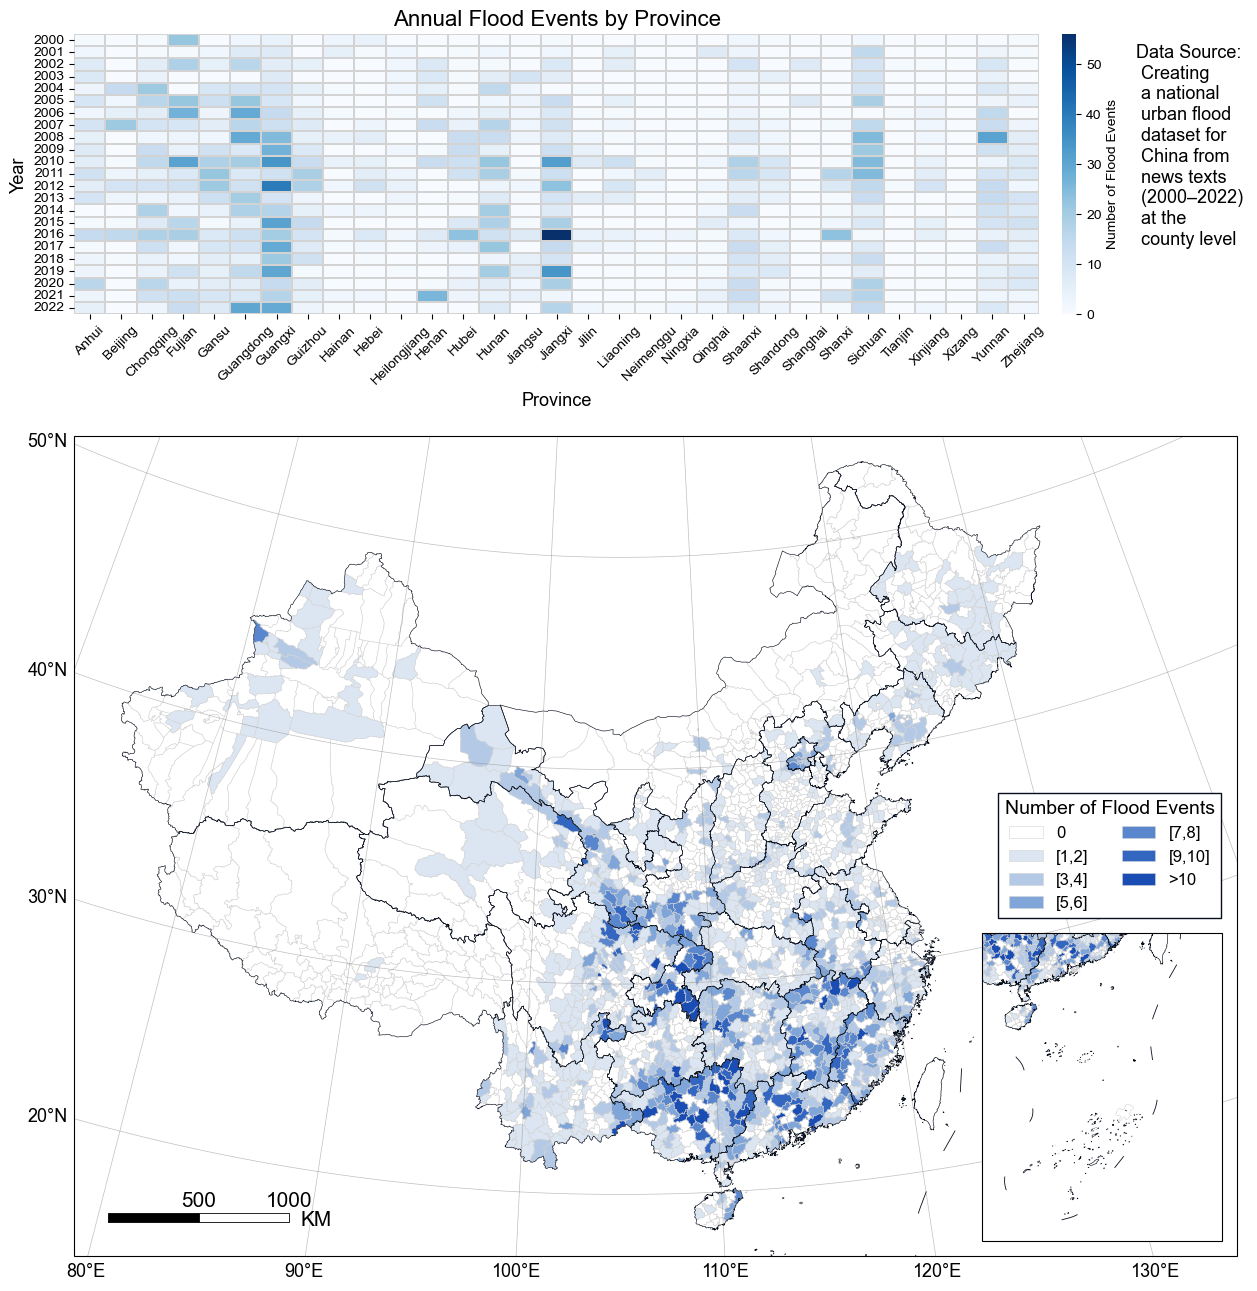

In [21]:
fig = plt.figure(figsize=(15, 16))
gs = GridSpec(
    2, 1, 
    height_ratios=[1, 3], 
    figure=fig
)

# 热力图
ax_heat = fig.add_subplot(gs[0])

sns.heatmap(
    data=heatmap_data,
    cmap='Blues',
    cbar=True,
    square=False,  # 不强制正方形单元格
    linewidths=0.1,  # 单元格边框宽度
    linecolor='lightgrey',  # 边框颜色
    xticklabels=True,
    yticklabels=True,
    cbar_kws={
        'label': 'Number of Flood Events',
        'pad': 0.02

    },
    ax=ax_heat
)
text_content = "Data Source: \n Creating \n a national \n urban flood \n dataset for \n China from \n news texts \n (2000–2022) \n at the \n county level"
ax_heat.text(
    x=1.1,
    y=0.6,
    s=text_content,
    fontsize=13,
    color='black',
    ha='left',
    va='center',
    rotation=0,
    transform=ax_heat.transAxes
)
ax_heat.set_title("Annual Flood Events by Province", fontsize=16)
ax_heat.set_xlabel("Province", fontsize=13)
ax_heat.set_ylabel("Year", fontsize=13)
ax_heat.tick_params(axis='x', labelrotation=45)  # 设置x刻度标签


# 空间分布图
ax = fig.add_subplot(gs[1:], projection=china_crs)

# 主图
province_proj.plot(
    ax=ax,
    facecolor='none',
    edgecolor='#060d1b',
    linewidth=0.4,
    zorder=2
)
ten_lines_proj.plot(
    ax=ax,
    color='#060d1b',
    linewidth=0.6,
    zorder=2
)
for i in range(len(colors)):
    gdf_proj.query(query_word[i]).plot(
        ax=ax,
        color=colors[i],
        lw=0.4,
        ec='lightgrey',
        zorder=1
    )
# 设置范围时仍然使用地理坐标系
ax.set_extent([78.5, 135, 17, 53], crs=ccrs.PlateCarree())
# 网格线使用地理坐标系标注
gl = ax.gridlines(
    crs=ccrs.PlateCarree(),
    draw_labels=True,
    linewidth=0.5,
    color='gray',
    alpha=0.5,
    linestyle='-'
)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlocator = mticker.FixedLocator(range(70, 141, 10))
gl.ylocator = mticker.FixedLocator(range(10, 61, 10))
gl.xlabel_style = {
    'rotation': 0, 
    'ha': 'center',
    'va': 'top',
    'size': 13
}
gl.ylabel_style = {
    'rotation': 0, 
    'va': 'center',
    'size': 13
}

# 子图
inset_pos = [0.73, 0.117, 0.16, 0.21]  # [left, bottom, width, height]
inset_ax = fig.add_axes(inset_pos, projection=china_crs)
# 筛选并转换子图区域的数据
southern_provinces = province[province['省'].isin(['广东省','广西壮族自治区','福建省','海南省','台湾省'])]
southern_provinces_proj = southern_provinces.to_crs(china_crs.proj4_init)
southern_provinces_proj.plot(
    ax=inset_ax,
    facecolor='none',
    edgecolor='#060d1b',
    linewidth=0.4,
    zorder=2
)
ten_lines_proj.plot(
    ax=inset_ax,
    color='#060d1b',
    linewidth=0.6,
    zorder=2
)
for i in range(len(colors)):
    gdf_proj.query(query_word[i]).plot(
        ax=inset_ax,
        color=colors[i],
        lw=0.4,
        ec='lightgrey',
        zorder=1
    )
inset_ax.set_extent([107, 122, 2, 24], crs=ccrs.PlateCarree())
inset_ax.set_xticks([])
inset_ax.set_yticks([])
inset_ax.set_xlabel('')
inset_ax.set_ylabel('')


# 指北针/比例尺
compass_scale_ax = fig.add_axes([0.125, 0.11, 0.15, 0.06], zorder=0)
plotscale(
    compass_scale_ax,
    bounds=province.total_bounds,
    textsize=15,
    compasssize=0.7,
    crs_is_projected=True,
    accuracy=125000,
    style=2
)
compass_scale_ax.axis('off')

# 图例
labels = ['0', '[1,2]', '[3,4]', '[5,6]', '[7,8]', '[9,10]', '>10']
legend_elements = [
    Patch(
        facecolor=colors[i],
        edgecolor='lightgrey',
        linewidth=0.4,
        label=labels[i],
    ) for i in range(len(colors))
]
ax.legend(
    handles=legend_elements,
    title='Number of Flood Events',
    title_fontsize=14,
    fontsize=12,
    loc='upper right',
    bbox_to_anchor=(0.994, 0.575),
    ncol=2,
    frameon=True,
    fancybox=False,
    edgecolor='#060d1b',
    framealpha=1,
    labelspacing=0.5
)

plt.savefig('空间分布', dpi=500, bbox_inches='tight')
plt.show()